# **Noteboo**k 9 – Data Transformation**

In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("customer_transaction_transformation_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction_ID          4000 non-null   object 
 1   Customer_Age            4000 non-null   int64  
 2   Annual_Income           4000 non-null   float64
 3   Purchase_Amount         4000 non-null   float64
 4   Transaction_Count       4000 non-null   int64  
 5   Discount_Percentage     4000 non-null   float64
 6   Customer_Tenure_Months  4000 non-null   int64  
 7   Delivery_Distance_Km    4000 non-null   float64
 8   Product_Rating          4000 non-null   float64
 9   Customer_Support_Calls  4000 non-null   int64  
 10  Monthly_Spend           4000 non-null   float64
 11  Returns_Count           4000 non-null   int64  
dtypes: float64(6), int64(5), object(1)
memory usage: 375.1+ KB


## **1. Why Transform Data?**



**Understand the Concept**

- Data transformation changes the form or distribution of numerical data.
- It can reduce skewness and make data easier to analyze.
- It can help machine learning models work better with certain features.



**Demonstrate the Concept**

**Example:**
- Compare the distribution of Annual_Income before and after transformation.

**AI/ML Usage:**
- Helps check whether the transformation improved the feature distribution.

In [30]:
# Implement the Concept
# distribution before transformation
print("Before Transformation")
print("Skewness:", df["Annual_Income"].skew())
# log transformation
df["Annual_Income_Log"] = np.log1p(df["Annual_Income"])

# distribution after transformation
print("\nAfter Transformation")
print("Skewness:", df["Annual_Income_Log"].skew())



Before Transformation
Skewness: 3.736923245916963

After Transformation
Skewness: 0.05751018260587127


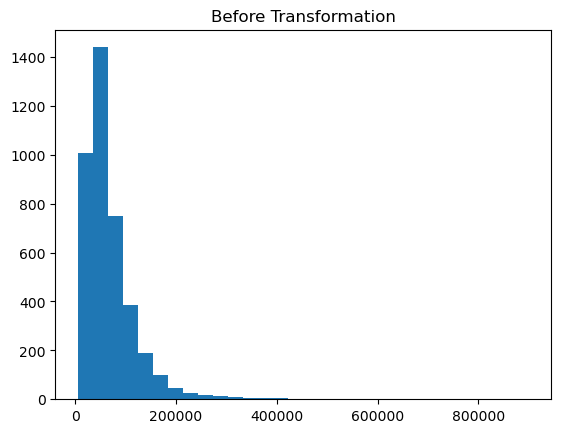

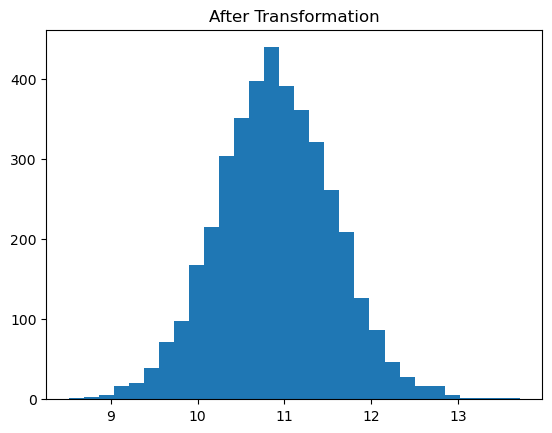

In [31]:
# Compare distributions
# Before transformation
plt.hist(df["Annual_Income"], bins=30)
plt.title("Before Transformation")
plt.show()

# After transformation
plt.hist(df["Annual_Income_Log"], bins=30)
plt.title("After Transformation")
plt.show()

**Explanation**

- skew() shows the skewness before and after transformation.
- log1p() reduces the effect of large values.
- Histograms help compare the distributions visually.

## **2. Log Transformation**



**Understand the Concept**

- Log Transformation reduces the effect of very large values.
- It is useful for right-skewed numerical data.
- It can make a highly skewed distribution more balanced.

**Demonstrate the Concept**

**Example:**
- Apply Log Transformation to Annual_Income.

**AI/ML Usage:**
- Helps models handle highly skewed numerical features.

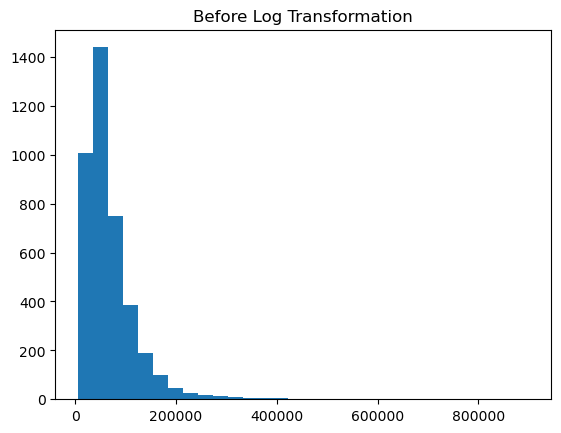

In [32]:
# Implement the Concept
# log transformation
df["Annual_Income_Log"] = np.log1p(df["Annual_Income"])

# Before Log Transformation 
plt.hist(df["Annual_Income"], bins=30)
plt.title("Before Log Transformation")
plt.show()



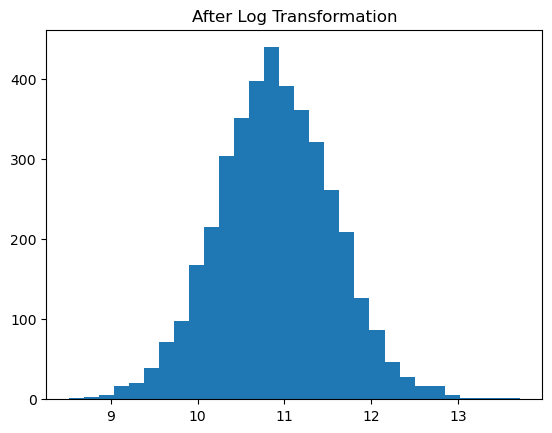

In [33]:
# After Log Transformation
plt.hist(df["Annual_Income_Log"], bins=30)
plt.title("After Log Transformation")
plt.show()

**Explanation**

- log1p() applies a logarithmic transformation safely.
- Large values are compressed more than smaller values.
- The histograms show the distribution before and after transformation.

## **3. Square Root Transformation**



**Understand the Concept**

- Square Root Transformation reduces the effect of large values.
- It is useful for moderately right-skewed data.
- It works well with non-negative numerical data.

**Demonstrate the Concept**

**Example:**
- Apply Square Root Transformation to Purchase_Amount.

**AI/ML Usage:**
- Helps reduce skewness in numerical features.

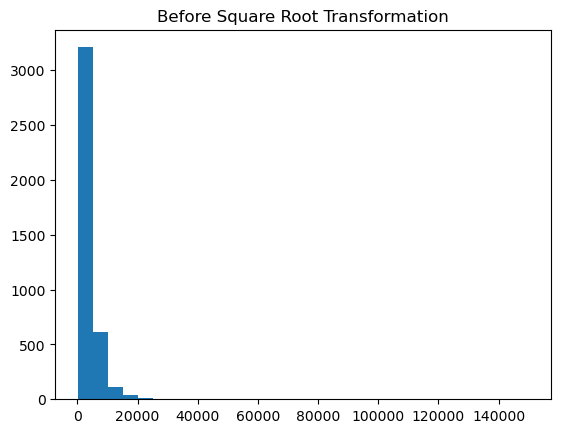

In [34]:
# Implement the Concept
# square root transformation
df["Purchase_Amount_Sqrt"] = np.sqrt(df["Purchase_Amount"])

# Before Square Root Transformation
plt.hist(df["Purchase_Amount"], bins=30)
plt.title("Before Square Root Transformation")
plt.show()

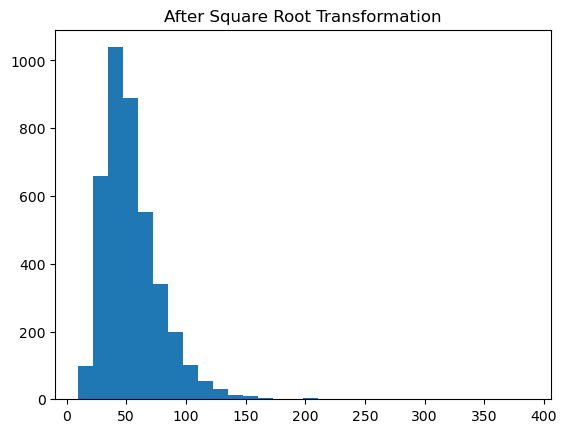

In [35]:
# After Square Root Transformation
plt.hist(df["Purchase_Amount_Sqrt"], bins=30)
plt.title("After Square Root Transformation")
plt.show()

**Explanation**

- sqrt() applies the square root transformation.
- Large values are reduced more than smaller values.
- Histograms show the distribution before and after transformation.

## **4. Power Transformation**



**Understand the Concept**

- Power Transformation changes the shape of numerical data.
- It can reduce skewness and make data more balanced.
- It is useful when the data is not normally distributed.

**Demonstrate the Concept**

**Example:**
- Apply Power Transformation to Monthly_Spend.

**AI/ML Usage:**
- Helps models work better with skewed numerical features.

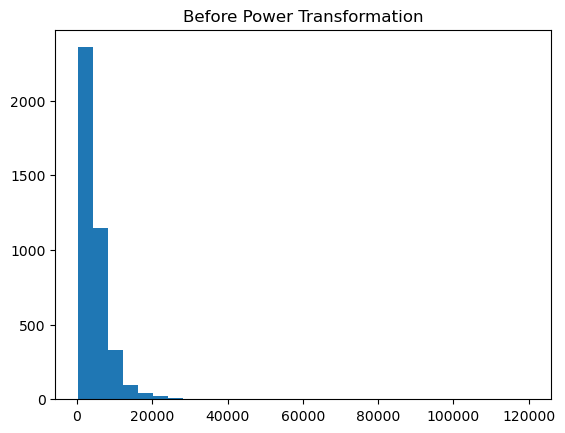

In [36]:
# Implement the Concept
from sklearn.preprocessing import PowerTransformer

# Power transformer
transformer = PowerTransformer(method="yeo-johnson")
df["Monthly_Spend_Power"] = transformer.fit_transform(df[["Monthly_Spend"]])

# Before Power Transformation
plt.hist(df["Monthly_Spend"], bins=30)
plt.title("Before Power Transformation")
plt.show()

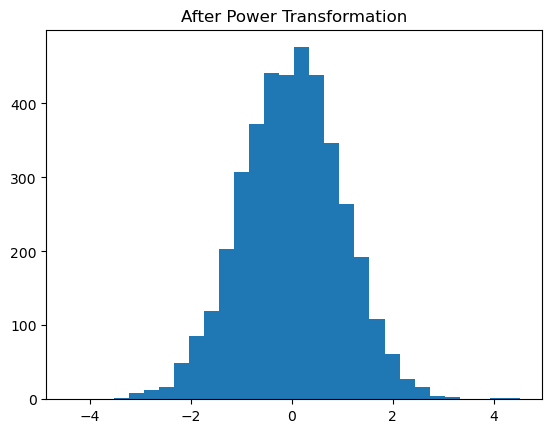

In [37]:
# After Power Transformation
plt.hist(df["Monthly_Spend_Power"], bins=30)
plt.title("After Power Transformation")
plt.show()

**Explanation**

- PowerTransformer changes the distribution of the feature.
- Yeo-Johnson can work with positive and negative values.
- Histograms help compare the distributions.

## **5. Box-Cox Transformation**



**Understand the Concept**

- Box-Cox Transformation reduces skewness in numerical data.
- It works only with positive values.
- It can make a distribution closer to normal.

**Demonstrate the Concept**

**Example:**
- Apply Box-Cox Transformation to Annual_Income.

**AI/ML Usage:**
- Helps improve the distribution of positive numerical features.

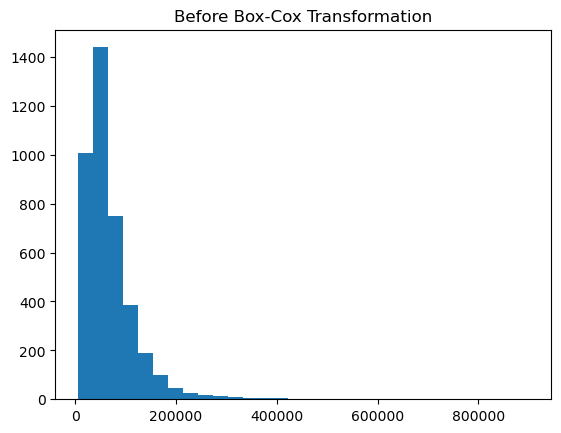

In [38]:
# Implement the Concept
# Box-cox transformer
transformer = PowerTransformer(method="box-cox")
df["Annual_Income_BoxCox"] = transformer.fit_transform(df[["Annual_Income"]])

# Before Box-Cox Transformation 
plt.hist(df["Annual_Income"], bins=30)
plt.title("Before Box-Cox Transformation")
plt.show()

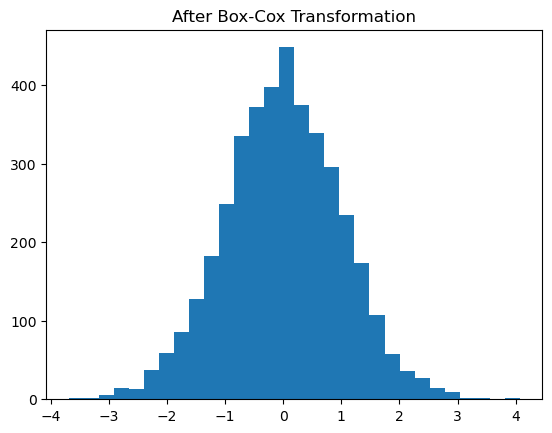

In [39]:
# After Box-Cox Transformation
plt.hist(df["Annual_Income_BoxCox"], bins=30)
plt.title("After Box-Cox Transformation")
plt.show()

**Explanation**

- Box-Cox transforms positive numerical values.
- It can reduce strong skewness.
- Histograms show the change in distribution.

## **6. Yeo-Johnson Transformation**



**Understand the Concept**

- Yeo-Johnson Transformation changes the distribution of numerical data.
- It can handle both positive and negative values.
- It is useful when data is skewed.

**Demonstrate the Concept**

**Example:**
- Apply Yeo-Johnson Transformation to Delivery_Distance_Km.

**AI/ML Usage:**
- Helps reduce skewness before applying machine learning algorithms.

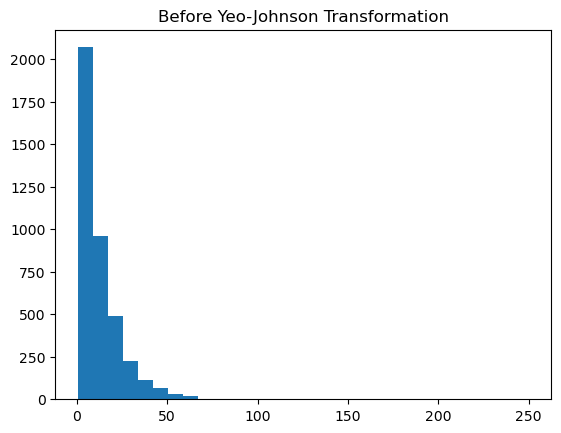

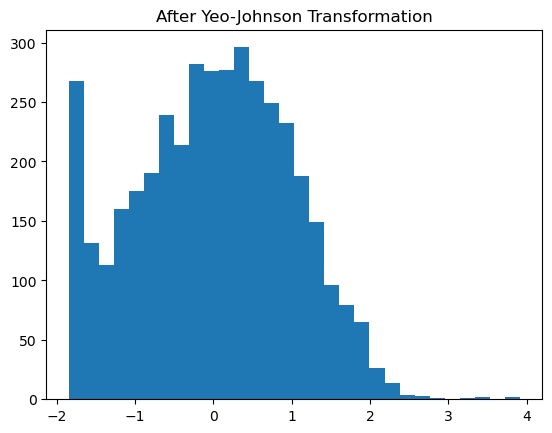

In [40]:
# Implement the Concept
# Yeo-Johnson Transformation
transformer = PowerTransformer(method="yeo-johnson")
df["Delivery_Distance_YeoJohnson"] = transformer.fit_transform(df[["Delivery_Distance_Km"]])

# Compare distributions
plt.hist(df["Delivery_Distance_Km"], bins=30)
plt.title("Before Yeo-Johnson Transformation")
plt.show()

plt.hist(df["Delivery_Distance_YeoJohnson"], bins=30)
plt.title("After Yeo-Johnson Transformation")
plt.show()

**Explanation**

- Yeo-Johnson transforms the feature to reduce skewness.
- It can handle zero and negative values.
- Histograms help compare the distributions.

## **7. Handling Skewed Data**



**Understand the Concept**

- Skewed data has an uneven distribution around its center.
- Right-skewed data has a longer tail toward larger values.
- Transformations can reduce skewness and make the distribution more balanced.

**Demonstrate the Concept**

**Example:**
- Check and reduce skewness in Annual_Income.

**AI/ML Usage:**
- Reducing skewness can improve the performance of some machine learning models.

In [41]:
# Implement the Concept

# skewness before transformation
print("Before:", df["Annual_Income"].skew())

# log transformation
df["Annual_Income_Log"] = np.log1p(df["Annual_Income"])

Before: 3.736923245916963


In [42]:
# skewness after transformation
print("After:", df["Annual_Income_Log"].skew())

After: 0.05751018260587127


**Explanation**

- skew() measures the skewness of the feature.
- log1p() reduces the effect of very large values.
- Comparing both values shows whether skewness was reduced.

## **8. Normalization**



**Understand the Concept**

- Normalization scales numerical values to a fixed range.
- A common range is 0 to 1.
- It is useful when features have very different ranges.

**Demonstrate the Concept**

**Example:**
- Normalize Purchase_Amount.

**AI/ML Usage:**
- Helps distance-based models work with features on a similar scale.

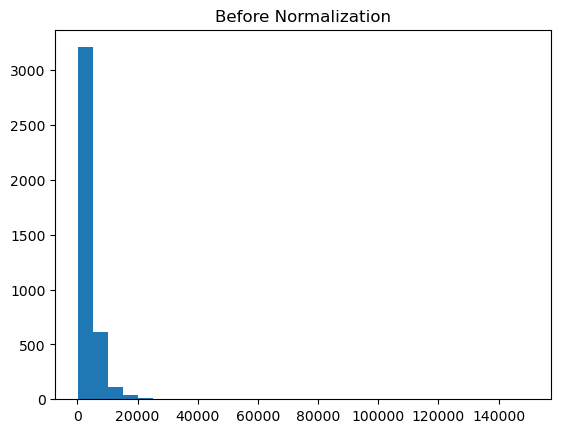

In [43]:
# Implement the Concept
from sklearn.preprocessing import MinMaxScaler

# MinMax Scaler
scaler = MinMaxScaler()
df["Purchase_Amount_Normalized"] = scaler.fit_transform(df[["Purchase_Amount"]])

# Before Normalization 
plt.hist(df["Purchase_Amount"], bins=30)
plt.title("Before Normalization")
plt.show()

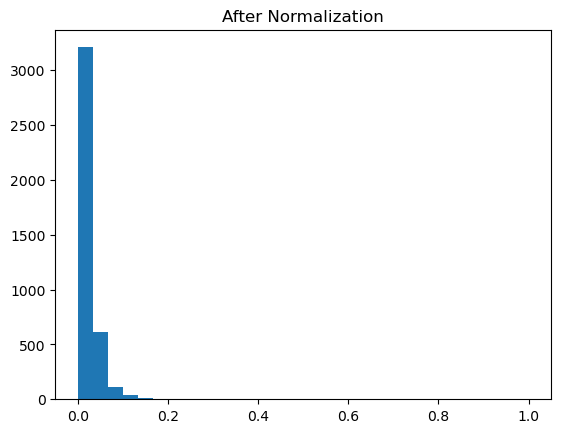

In [44]:
# After Normalization
plt.hist(df["Purchase_Amount_Normalized"], bins=30)
plt.title("After Normalization")
plt.show()

**Explanation**

- MinMaxScaler scales values between 0 and 1.
- The original values are converted to a common range.
- Histograms show the distribution before and after scaling.

## **9. Standardization**



**Understand the Concept**

- Standardization centers data around a mean of 0.
- It scales the data using the standard deviation.
- It is useful when features have different ranges.

**Demonstrate the Concept**

**Example:**
- Standardize Monthly_Spend.

**AI/ML Usage:**
- Helps scale-sensitive models work with features on a common scale.

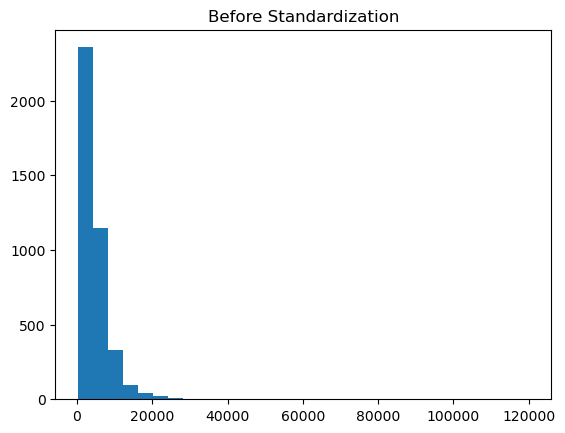

In [45]:
# Implement the Concept
from sklearn.preprocessing import StandardScaler

# Standard Scaler
scaler = StandardScaler()
df["Monthly_Spend_Standardized"] = scaler.fit_transform(df[["Monthly_Spend"]])

# Before Standardization
plt.hist(df["Monthly_Spend"], bins=30)
plt.title("Before Standardization")
plt.show()

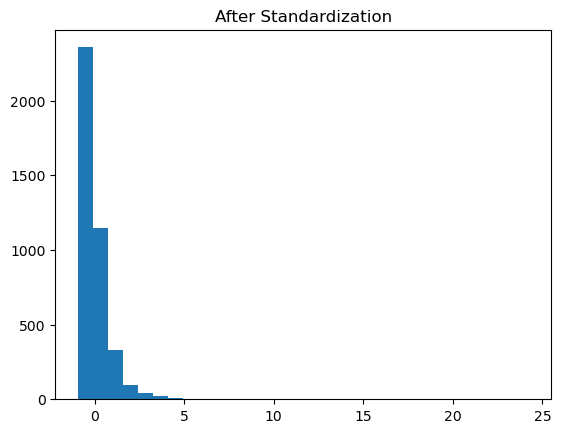

In [46]:
# After Standardization
plt.hist(df["Monthly_Spend_Standardized"], bins=30)
plt.title("After Standardization")
plt.show()

**Explanation**

- StandardScaler centers the feature around 0.
- It scales values using the standard deviation.
- Histograms show the distribution before and after standardization.